In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
df = pd.read_csv("24-medical_cost.csv")

In [3]:
df.head()

,Id,age,sex,bmi,children,smoker,region,charges
0,1,19,female,27.900,0,yes,southwest,16884.92400
1,2,18,male,33.770,1,no,southeast,1725.55230
2,3,28,male,33.000,3,no,southeast,4449.46200
3,4,33,male,22.705,0,no,northwest,21984.47061
4,5,32,male,28.880,0,no,northwest,3866.85520


In [4]:
df.tail()

,Id,age,sex,bmi,children,smoker,region,charges
1333,1334,50,male,30.97,3,no,northwest,10600.5483
1334,1335,18,female,31.92,0,no,northeast,2205.9808
1335,1336,18,female,36.85,0,no,southeast,1629.8335
1336,1337,21,female,25.80,0,no,southwest,2007.9450
1337,1338,61,female,29.07,0,yes,northwest,29141.3603


<Axes: xlabel='sex', ylabel='count'>

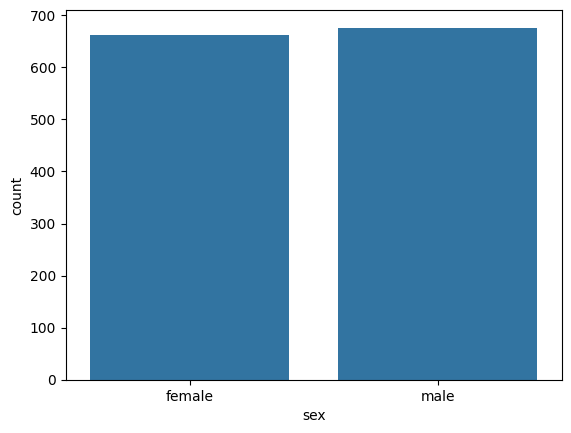

In [5]:
sns.countplot(data=df, x="sex")

<Axes: xlabel='smoker', ylabel='count'>

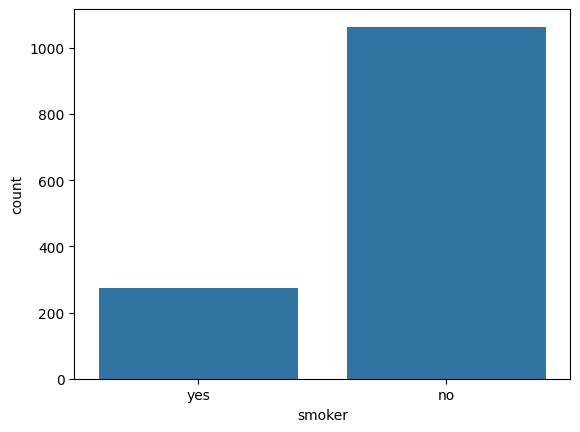

In [6]:
sns.countplot(data=df, x="smoker")

<Axes: xlabel='region', ylabel='count'>

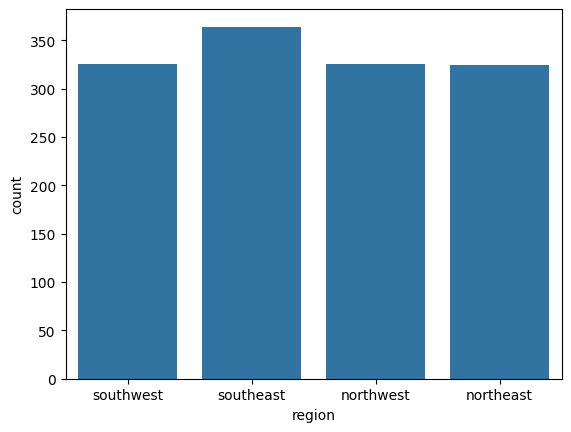

In [7]:
sns.countplot(data=df, x="region")

<Axes: xlabel='children', ylabel='count'>

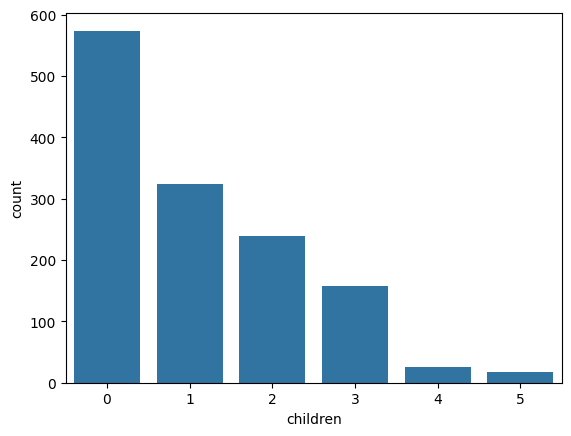

In [8]:
sns.countplot(data=df, x="children")

<Axes: xlabel='age', ylabel='charges'>

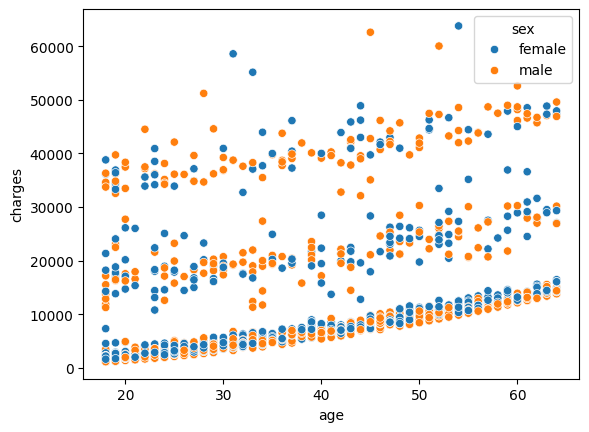

In [9]:
sns.scatterplot(data=df, x="age", y="charges", hue="sex")

<Axes: xlabel='age', ylabel='charges'>

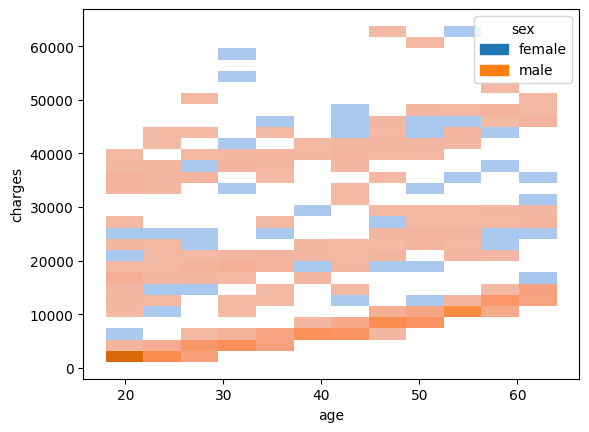

In [10]:
sns.histplot(data=df, x="age", y="charges", hue="sex")

<Axes: xlabel='bmi', ylabel='Count'>

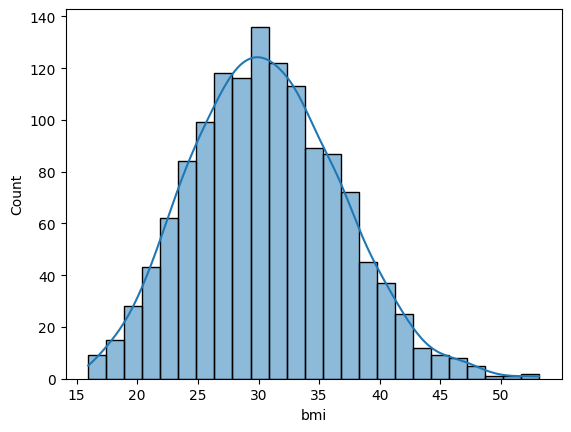

In [11]:
sns.histplot(data=df, x="bmi", kde=True)

<Axes: xlabel='charges', ylabel='Count'>

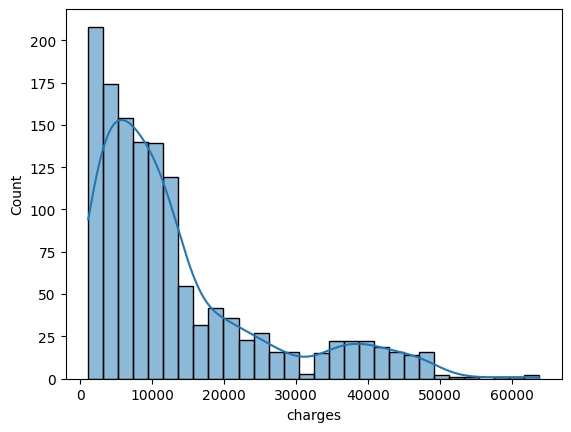

In [12]:
sns.histplot(data=df, x="charges", kde=True)

In [13]:
df.drop("Id", inplace=True, axis=1)

In [14]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [15]:
df["sex"] = df["sex"].map({"male" : 0, "female" : 1})
df["smoker"] = df["smoker"].map({"no" : 0, "yes" : 1})
                          

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   int64  
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   int64  
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(4), object(1)
memory usage: 73.3+ KB


In [17]:
# one hot encoding -> region

In [18]:
from sklearn.model_selection import train_test_split

In [21]:
from lightgbm import LGBMRegressor

In [29]:
df['region'] = df['region'].astype('category')

X = df.drop('charges', axis=1)
y = df['charges']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


model = LGBMRegressor()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000265 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 318
[LightGBM] [Info] Number of data points in the train set: 1070, number of used features: 6
[LightGBM] [Info] Start training from score 13346.089733


In [30]:
#categorical_cols = ["region"]

#preprocessor = ColumnTransformer(transformers=
                              #  [
                                #    ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_cols)],
                                #    remainder = "passthrough"
                               # )

In [31]:
X_train

,age,sex,bmi,children,smoker,region
560,46,1,19.950,2,0,northwest
1285,47,1,24.320,0,0,northeast
1142,52,1,24.860,0,0,southeast
969,39,1,34.320,5,0,southeast
486,54,1,21.470,3,0,northwest
...,...,...,...,...,...,...
1095,18,1,31.350,4,0,northeast
1130,39,1,23.870,5,0,southeast
1294,58,0,25.175,0,0,northeast
860,37,1,47.600,2,1,southwest


In [32]:
model = LGBMRegressor()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
model = LGBMRegressor()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000320 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 318
[LightGBM] [Info] Number of data points in the train set: 1070, number of used features: 6
[LightGBM] [Info] Start training from score 13346.089733
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000181 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 318
[LightGBM] [Info] Number of data points in the train set: 1070, number of used features: 6
[LightGBM] [Info] Start training from score 13346.089733


In [33]:
from sklearn.metrics import r2_score, mean_squared_error

In [34]:
print(r2_score(y_pred, y_test))
print(mean_squared_error(y_pred, y_test))

0.8500010921347384
20873981.9019942


In [35]:
#hyperparameter tuning

In [36]:
param_grid = {
    "num_leaves": [31,50,70],
    "max_depth": [-1, 5, 10],
    "learning_rate": [0.01, 0.05, 0.1, 0.5, 1.0],
    "n_estimators": [100,150, 300, 1000],
    "min_child_samples": [10,20,30],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "reg_alpha":[0,0.5, 1.0],
    "reg_lambda":[0,0.5, 1.0]
}

In [37]:
from sklearn.model_selection import RandomizedSearchCV

In [38]:
import warnings
warnings.filterwarnings("ignore")

In [40]:
random_search = RandomizedSearchCV(
    estimator=LGBMRegressor(verbosity=-1),
    param_distributions=param_grid,
    cv=5,
    verbose=0,
    random_state=15,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1)

In [41]:
random_search.fit(X_train, y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LGBMRegressor(verbosity=-1)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': [0.6, 0.8, ...], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [-1, 5, ...], 'min_child_samples': [10, 20, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strate

In [42]:
random_search.best_params_

{'subsample': 0.6,
 'reg_lambda': 0,
 'reg_alpha': 0.5,
 'num_leaves': 50,
 'n_estimators': 1000,
 'min_child_samples': 10,
 'max_depth': 5,
 'learning_rate': 0.01,
 'colsample_bytree': 1.0}

In [43]:
y_pred = random_search.predict(X_test)

In [44]:
print(r2_score(y_pred, y_test))
print(mean_squared_error(y_pred, y_test))

0.8595312818123968
19444247.13891273


In [45]:
from scipy.stats import boxcox

In [46]:
y_train_transformed, lambda_y = boxcox(y_train)

In [47]:
model = LGBMRegressor()
model.fit(X_train, y_train_transformed)

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [48]:
y_pred_transformed = model.predict(X_test)

In [49]:
print(r2_score(y_pred, y_test))
print(mean_squared_error(y_pred, y_test))

0.8595312818123968
19444247.13891273


In [50]:
# (inverse Box-Cox)
def inverse_boxcox(y, lambda_):
    if lambda_ == 0:
        return np.exp(y)
    else:
        return np.power(y * lambda_ + 1, 1 / lambda_)

In [51]:
y_pred_original = inverse_boxcox(y_pred_transformed, lambda_y)

                                

In [53]:
print(r2_score(y_pred_original, y_test))
print(mean_squared_error(y_pred_original, y_test))

0.8594752180730627
19393431.521655764
